Loading CIFAR-10 data for CNN...
Building the CNN model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Training the CNN model... (This may take 5-10 minutes on CPU)
Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.4260 - loss: 1.5736 - val_accuracy: 0.5577 - val_loss: 1.2495
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.5663 - loss: 1.2089 - val_accuracy: 0.6135 - val_loss: 1.0887
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.6247 - loss: 1.0530 - val_accuracy: 0.6689 - val_loss: 0.9519
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.6647 - loss: 0.9491 - val_accuracy: 0.6983 - val_loss: 0.8680
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.6876 - loss: 0.8787 - val_accuracy: 0.7099 - val_loss: 0.8341
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.7130 - loss: 0.8160 - val_accuracy: 0.7281 - val_loss: 0.7743
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.7279 - loss: 0.7673 - val_accuracy: 0.7402 - val_loss: 0.7477
Epoch 8/15
625/625 ━━━━━━━━━

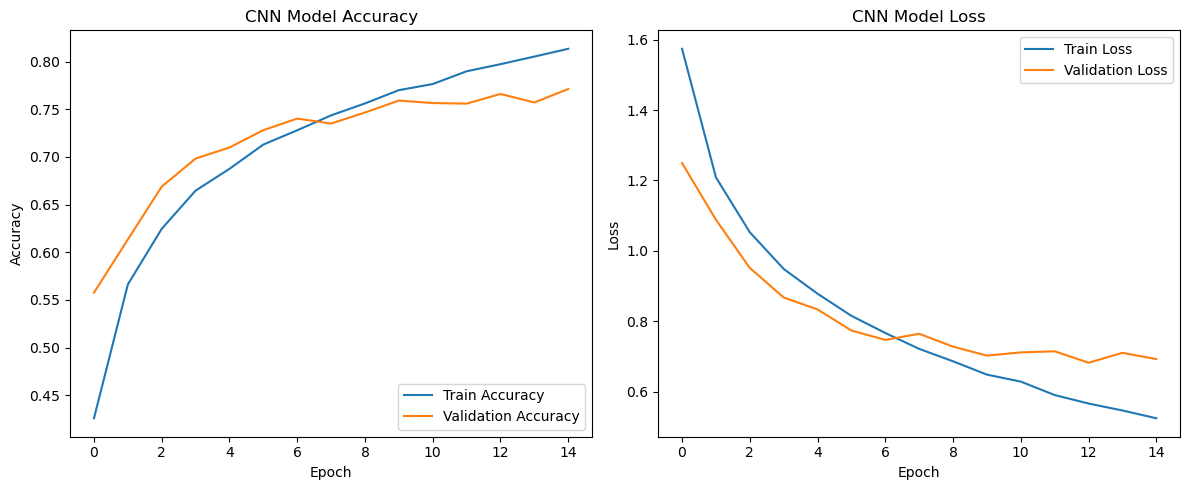

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10

# 1. Load and Preprocess Data
print("Loading CIFAR-10 data for CNN...")
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train_full.astype('float32') / 255.0
x_test = x_test_full.astype('float32') / 255.0

y_train = y_train_full.flatten()
y_test = y_test_full.flatten()

# 2. Define the CNN Architecture
print("Building the CNN model...")
model_cnn = Sequential([
    # Input layer explicitly defined to avoid warnings
    Input(shape=(32, 32, 3)),
    
    # First Convolutional Block
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Second Convolutional Block
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Third Convolutional Block
    Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Fully Connected (Dense) Classifier Stage
    Flatten(),
    Dropout(0.5), # High dropout to prevent overfitting in CNN
    Dense(128, activation='relu'),
    Dense(10, activation='softmax') # 10 classes
])

# 3. Compile the model
model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_cnn.summary()

# 4. Train the model
print("Training the CNN model... (This may take 5-10 minutes on CPU)")
history_cnn = model_cnn.fit(x_train, y_train, 
                            epochs=15, 
                            batch_size=64, 
                            validation_split=0.2, 
                            verbose=1)

# 5. Evaluate on Test Data
print("\nEvaluating CNN on test data...")
test_loss, test_acc = model_cnn.evaluate(x_test, y_test, verbose=0)
print(f"CNN Test Accuracy: {test_acc:.4f}")

# 6. Plot Training and Validation Curves
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()